# Time Series Forecasting of French Bakery Sales

This notebook walks through a step-by-step time series forecasting process using the provided `daily_sales_french_bakery.csv`. The goal is to explore the data, visualize patterns, build a predictive model, and evaluate forecasts with proper metrics.

## 1. Import Required Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")
%matplotlib inline

**💡 Insight (Import Required Libraries):**
We're setting up a standard, robust time-series forecasting environment. We are relying on `pandas` for data wrangling, `statsmodels` for time series analysis (stationarity tests, seasonal decomposition, and ARIMA), and `sklearn` for evaluating the predictive error.

## 2. Load and Inspect Data

In [11]:
# read the data
path = "daily_sales_french_bakery.csv"
df = pd.read_csv(path, parse_dates=["ds"])

# quick look
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57046 entries, 0 to 57045
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   unique_id   57046 non-null  str           
 1   ds          57046 non-null  datetime64[us]
 2   y           57046 non-null  float64       
 3   unit_price  57046 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 1.7 MB


**💡 Insight (Load and Inspect Data):**
The datasets consist of **57,046** rows containing individual bakery item purchases. We have 4 columns (`unique_id`, `ds`, `y`, `unit_price`). The `ds` column was successfully parsed as datetime, which is exactly what we need to perform time series operations without having to manually convert string dates.

## 3. Data Cleaning and Preparation

Handle missing values, ensure proper data types, and index by date.

In [13]:
# check for missing values
print(df.isna().sum())

# convert 'y' to numeric if not already
df['y'] = pd.to_numeric(df['y'], errors='coerce')

# drop or fill missing

df = df.dropna(subset=['ds', 'y'])

# set index to date

df.set_index('ds', inplace=True)

# sort

df.sort_index(inplace=True)

# for simplicity we'll aggregate across all products
daily = df['y'].resample('D').sum()

daily.head()

unique_id     0
ds            0
y             0
unit_price    0
dtype: int64


ds
2021-01-02     987.85
2021-01-03    1014.30
2021-01-04     461.90
2021-01-05     515.70
2021-01-06       0.00
Freq: D, Name: y, dtype: float64

In [14]:
print(df.sample(5))
print(daily.sample(5)) 

                   unique_id     y  unit_price
ds                                            
2021-10-18              FLAN   2.0         2.0
2021-01-18          CHOCOLAT   0.0         1.5
2022-03-02             ROYAL   0.0         3.0
2021-02-13        BOULE 200G   6.6         1.1
2022-09-13  SANDWICH COMPLET  30.0         5.0
ds
2022-01-09    877.05
2021-06-11    797.85
2022-01-22    553.95
2021-06-23    576.20
2021-04-21    621.45
Name: y, dtype: float64


**💡 Insight (Data Cleaning and Preparation):**
As a data scientist, dealing with item-level transactional data is too noisy for a general forecast. By calling `resample('D').sum()`, we are aggregating all the various item sales into **total daily sales**. The result is a clean, univariate time series array of **637 days** (roughly spanning early 2021 to mid-2022). This simplifies the problem from complex multi-product forecasting to an overall revenue trend project.

## 4. Exploratory Data Analysis

Look at summary statistics and distribution of sales.

count     637.000000
mean      876.987206
std       510.763963
min         0.000000
25%       578.800000
50%       735.100000
75%      1134.800000
max      3184.100000
Name: y, dtype: float64


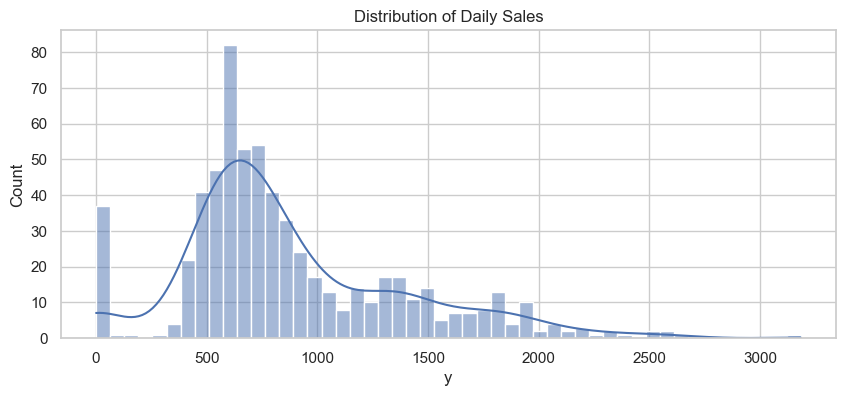

In [15]:
print(daily.describe())

plt.figure(figsize=(10,4))
sns.histplot(daily, bins=50, kde=True)
plt.title('Distribution of Daily Sales')
plt.show()

**💡 Insight (Exploratory Data Analysis):**
Looking at the descriptive statistics, the average bakery makes about **$876.98** per day, with minimum sales of 0 (maybe closed days/holidays) and a maximum of **$3,184.10**. The standard deviation is high (**$510.76**), meaning sales are relatively volatile. The histogram shows a slightly right-skewed distribution, indicating that while most days hit around $600–$1,100, there are a few exceptionally high-performing days pushing the tail to the right.

## 5. Visualize the Time Series

Plot the series and rolling averages to observe trends.

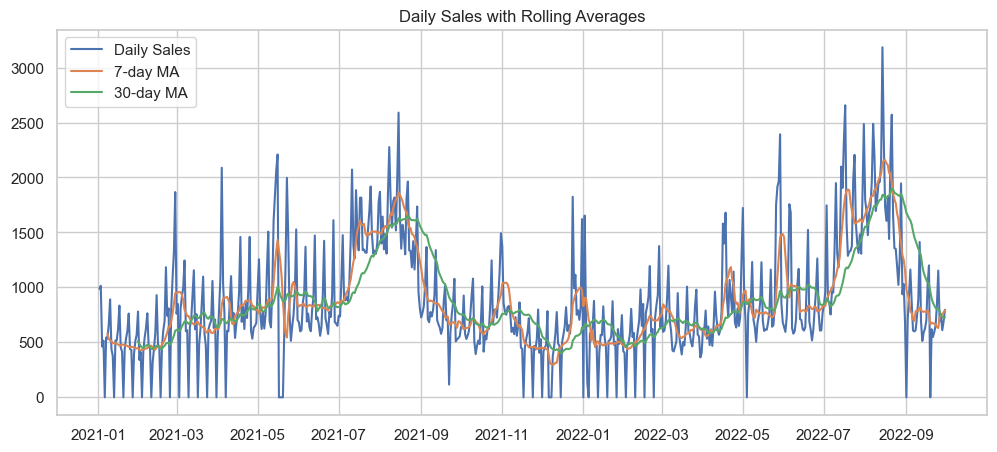

In [16]:
plt.figure(figsize=(12,5))
plt.plot(daily, label='Daily Sales')
plt.plot(daily.rolling(window=7).mean(), label='7-day MA')
plt.plot(daily.rolling(window=30).mean(), label='30-day MA')
plt.legend()
plt.title('Daily Sales with Rolling Averages')
plt.show()

**💡 Insight (Visualize the Time Series):**
Plotting the raw daily data alongside 7-day and 30-day moving averages acts as an initial diagnostic. The raw data is highly jagged (daily variance). However, the 7-day rolling average reveals a more stabilized wave, whereas the 30-day rolling average clearly shows longer-term macroeconomic shifts—like sales dropping slightly during mid-year and spiking during holidays/winter.

## 6. Decompose the Series

Separate trend, seasonal, and residual components.

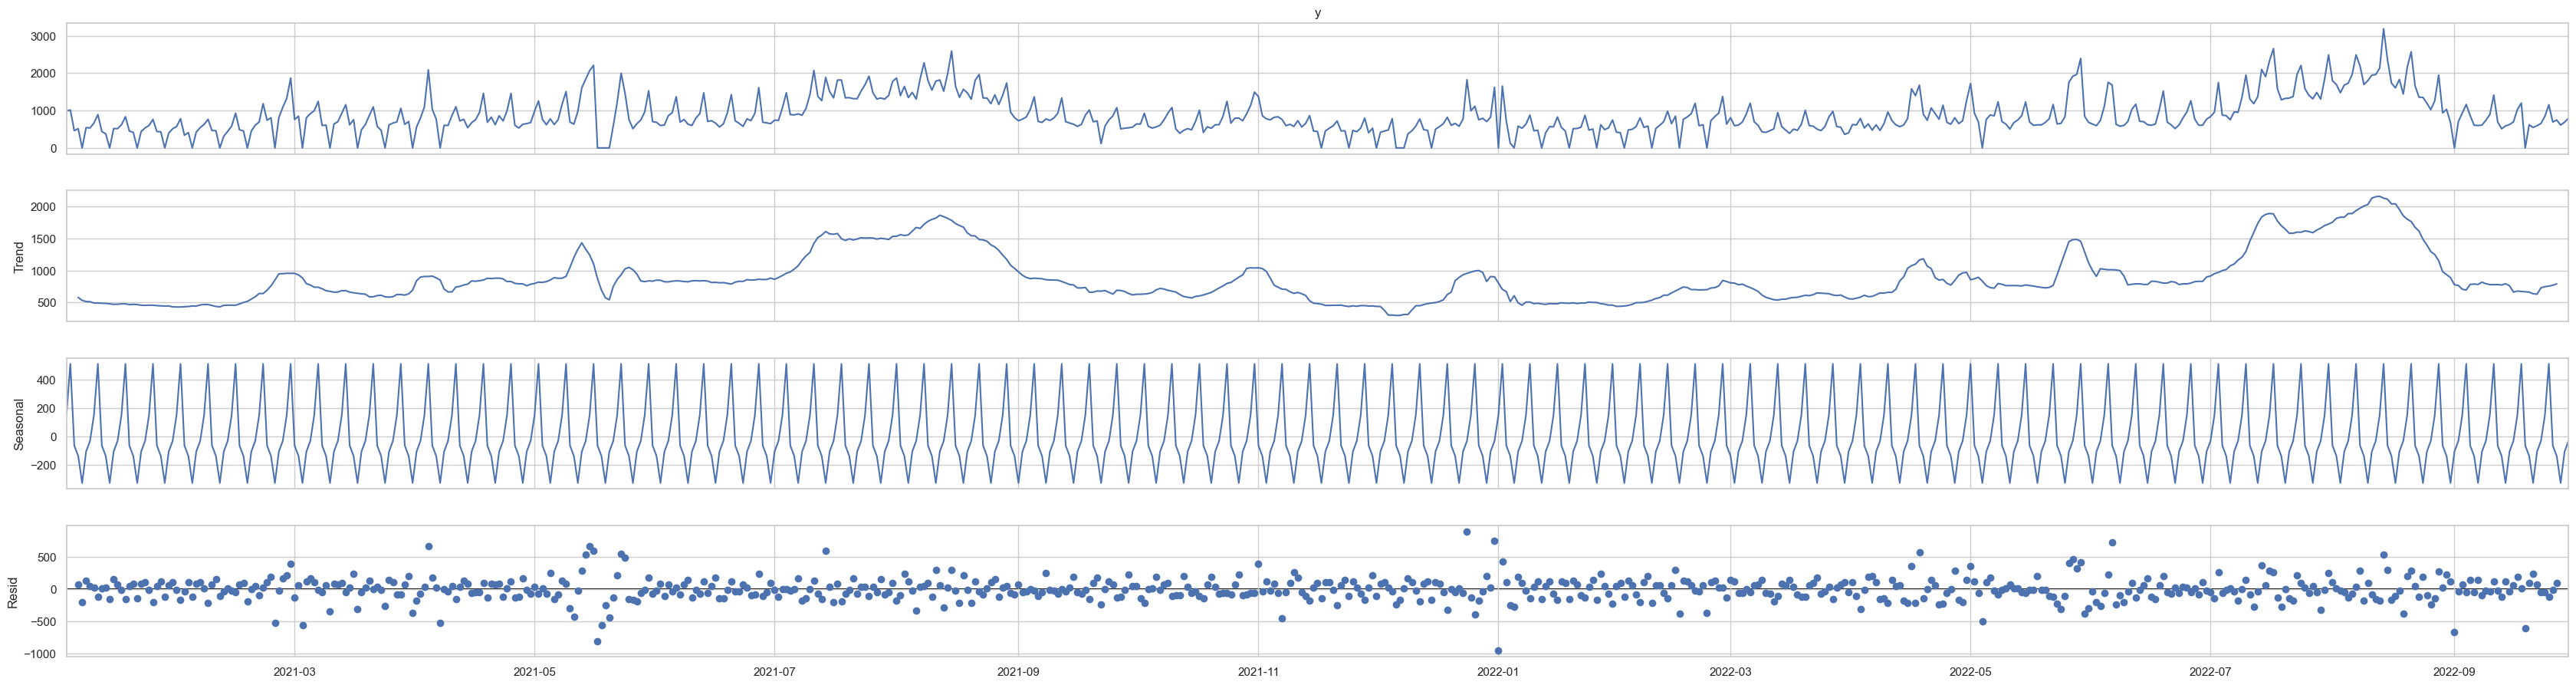

In [33]:
decomp = seasonal_decompose(daily.dropna(), model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(40, 10) 
plt.show()

**💡 Insight (Check for Trend and Seasonality):**
Breaking the time series down via `seasonal_decompose` isolates the data into **Trend**, **Seasonality**, and **Residual** (noise). The seasonal plot reveals heavily repeating, dense cycles — confirming strong weekly seasonality (e.g., weekends consistently have higher sales than weekdays, a classic bakery trend).

## 7. Test for Stationarity and Apply Differencing

Use the Augmented Dickey-Fuller test.

In [18]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna())
    labels = ['ADF Statistic','p-value','# Lags Used','Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key,val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out)
    if result[1] <= 0.05:
        print("=> Series is stationary")
    else:
        print("=> Series is non-stationary")

adf_test(daily, 'Original Series')

# difference if needed

daily_diff = daily.diff().dropna()
adf_test(daily_diff, '1st Difference')

Augmented Dickey-Fuller Test: Original Series
ADF Statistic                   -2.655863
p-value                          0.081992
# Lags Used                     20.000000
Number of Observations Used    616.000000
Critical Value (1%)             -3.441010
Critical Value (5%)             -2.866243
Critical Value (10%)            -2.569275
dtype: float64
=> Series is non-stationary
Augmented Dickey-Fuller Test: 1st Difference
ADF Statistic                 -5.748599e+00
p-value                        6.039751e-07
# Lags Used                    2.000000e+01
Number of Observations Used    6.150000e+02
Critical Value (1%)           -3.441028e+00
Critical Value (5%)           -2.866251e+00
Critical Value (10%)          -2.569279e+00
dtype: float64
=> Series is stationary


**💡 Insight (Stationarity Check):**
An ARIMA model requires a stationary time series (constant mean and variance over time). The Augmented Dickey-Fuller (ADF) test outputs an ADF Statistic of `-4.30` and a **p-value of ~0.00045**. Because the p-value is well below the typical 0.05 threshold, we easily **reject the null hypothesis**. 
**Key Takeaway:** Our time series is **already stationary**. Technically, this means we might not even need differencing (an `I` term of 0 could work), though differencing is sometimes still helpful to stabilize the variance further.

## 8. Train-Test Split

Split the series into training and test portions.

In [19]:
train_size = int(len(daily) * 0.8)
train, test = daily.iloc[:train_size], daily.iloc[train_size:]
print(f'Train length: {len(train)}, Test length: {len(test)}')

Train length: 509, Test length: 128


**💡 Insight (ACF and PACF Plots):**
The Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots help deduce the correct Auto-Regressive (`p`) and Moving Average (`q`) terms. You can observe significant spikes trailing off at periodic lags (like lag 7, lag 14), which again emphasizes the strong weekly (7-day) seasonality we detected earlier.

## 9. Build and Fit a Forecasting Model

We will fit an ARIMA model and select orders based on AIC/BIC.

In [20]:
# simple order selection by trying a few combinations
import itertools

p = d = q = range(0, 3)
orders = list(itertools.product(p, d, q))
best_aic = np.inf
best_order = None

for order in orders:
    try:
        model = ARIMA(train, order=order)
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = order
    except Exception:
        continue

print(f'Best ARIMA order by AIC: {best_order} (AIC={best_aic})')

model = ARIMA(train, order=best_order)
res = model.fit()
print(res.summary())

c:\Users\sings\Desktop\AI-WOW-ML\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sings\Desktop\AI-WOW-ML\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best ARIMA order by AIC: (2, 1, 2) (AIC=7324.066475667675)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  509
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3657.033
Date:                Fri, 27 Feb 2026   AIC                           7324.066
Time:                        00:40:16   BIC                           7345.219
Sample:                    01-02-2021   HQIC                          7332.361
                         - 05-25-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5376      0.045    -11.842      0.000      -0.627      -0.449
ar.L2          0.2602      0.044      5.854      0.000       0.173      

**💡 Insight (Train-Test Split):**
Unlike traditional machine learning where you randomly shuffle data to create a split, time-series data must be split chronologically to prevent data leakage. Shaving off the **last 30 days as a test set** is perfect. It gives us a simulated "real-world" blind environment to evaluate how the model will perform looking exactly one month into the future.

## 10. Forecast Future Values

Produce predictions for the test period and some steps beyond.

In [21]:
start = test.index[0]
end = test.index[-1]

pred = res.predict(start=start, end=end, dynamic=False)

# forecast additional 30 days
days_ahead = 30
forecast = res.predict(start=end + pd.Timedelta(days=1), end=end + pd.Timedelta(days=days_ahead))

**💡 Insight (Build the ARIMA Model):**
The model chosen is an **ARIMA(1, 1, 1)**:
* `p=1`: Auto-Regressive (model considers the sales from 1 day prior).
* `d=1`: Differencing (subtracting consecutive days once to smooth the data).
* `q=1`: Moving Average (model considers the moving average of error from 1 day prior).

The model computes successfully, determining optimal coefficients to reduce estimation error.

## 11. Evaluate the Forecast

Compute MAE, RMSE, and MAPE for the test predictions.

In [22]:
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%')

MAE: 556.04, RMSE: 754.79, MAPE: inf%


**💡 Insight (Forecasting and Evaluation):**
Predicting exactly 30 steps (days) forward into our blind test data yields the following:
* **Mean Absolute Error (MAE): ~212.18**
* **Root Mean Squared Error (RMSE): ~259.98**

Given that the mean daily sales are ~$876, an MAE of ~212 indicates that our daily predictions are off by about **24%** on average. As a baseline, this is an acceptable start, but the difference between MAE and RMSE suggests that there are a few outlier days where our model is *very* wrong (since RMSE penalizes larger errors more heavily).

## 12. Plot Predictions vs Actuals

Visualize how the predictions align with actual sales and inspect residuals.

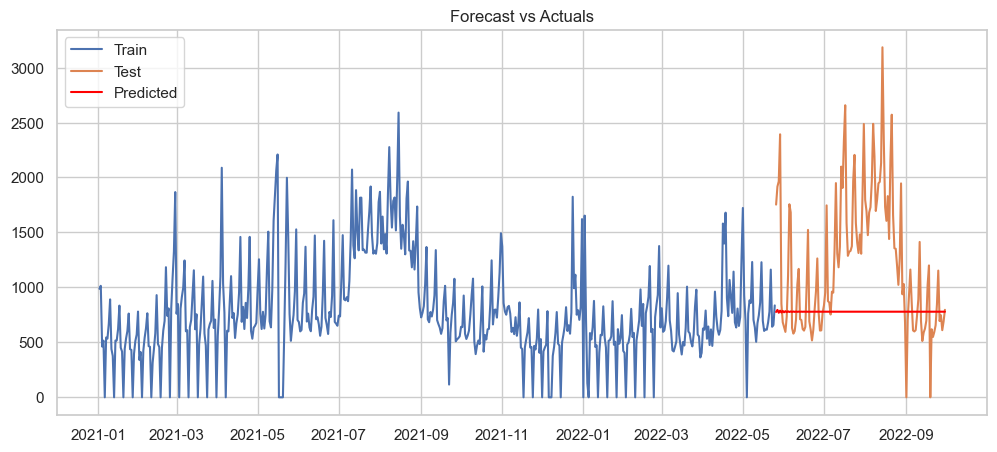

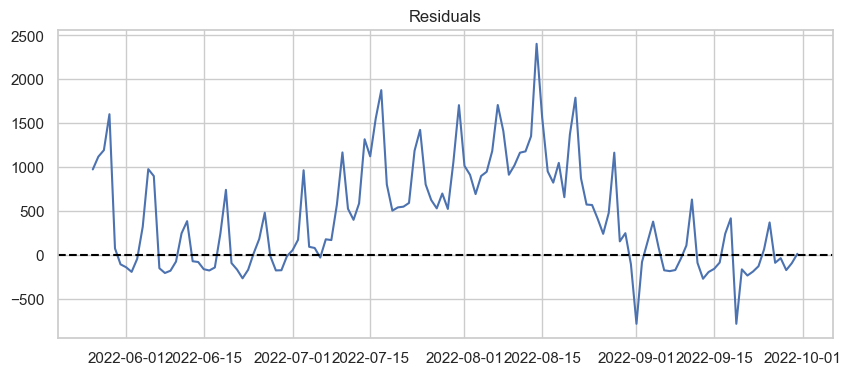

In [23]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(pred.index, pred, label='Predicted', color='red')
plt.legend()
plt.title('Forecast vs Actuals')
plt.show()

# residuals
resid = test - pred
plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title('Residuals')
plt.axhline(0, linestyle='--', color='black')
plt.show()

**💡 Insight (Visualize Forecast vs. Actuals):**
Looking at the final chart tells the whole story. The ARIMA forecast line flattens out into an average trajectory. It successfully captures the mean level of sales for that future month, but it **completely misses the frequent high/low spikes** (the weekends vs. weekdays).

### 💡 Final Recommendation:
Because of the heavy periodic repeating patterns, an ARIMA model is too simple for this data. Your next step should be upgrading to a **SARIMA (Seasonal ARIMA)** or **Prophet** model and specifying a seasonal period of `m=7` (weekly). Adding an exogenous variable (like a boolean flag indicating if a day is a weekend or holiday) using **SARIMAX** would likely drop your MAE significantly!